In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
SAVE_DIR = 'outputs/'
PALETTE = ['#9C27B0','#FF5722','#4CAF50','#2196F3','#FF9800','#00BCD4','#E91E63']

In [ ]:
# load dataset
df = pd.read_csv('Airline_Delay_Cause.csv', encoding='utf-8')
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [ ]:
df.info()
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82348 entries, 0 to 82347
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 82348 non-null  int64  
 1   month                82348 non-null  int64  
 2   carrier              82348 non-null  object 
 3   carrier_name         82348 non-null  object 
 4   airport              82348 non-null  object 
 5   airport_name         82348 non-null  object 
 6   arr_flights          82206 non-null  float64
 7   arr_del15            82024 non-null  float64
 8   carrier_ct           82206 non-null  float64
 9   weather_ct           82206 non-null  float64
 10  nas_ct               82206 non-null  float64
 11  security_ct          82206 non-null  float64
 12  late_aircraft_ct     82206 non-null  float64
 13  arr_cancelled        82206 non-null  float64
 14  arr_diverted         82206 non-null  float64
 15  arr_delay            82206 non-null 

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,82348.00,82348.00,82206.00,82024.00,82206.00,82206.00,82206.00,82206.00,82206.00,82206.00,82206.00,82206.00,82206.00,82206.00,82206.0,82206.00,82206.00
mean,2021.06,6.57,314.46,55.36,19.57,2.11,14.65,0.18,18.73,8.45,0.73,3730.27,1411.99,218.57,697.8,8.40,1393.50
std,1.26,3.40,890.94,162.51,52.04,7.55,50.34,0.85,64.18,55.46,3.33,12264.31,4575.43,866.05,2758.6,47.36,5084.79
min,2019.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
25%,2020.00,4.00,38.00,5.00,1.86,0.00,0.47,0.00,0.85,0.00,0.00,243.00,81.00,0.00,16.0,0.00,28.00
50%,2021.00,7.00,87.00,13.00,5.22,0.20,2.73,0.00,3.31,1.00,0.00,797.00,304.00,10.00,101.0,0.00,211.00
75%,2022.00,9.00,211.00,37.00,15.00,1.68,8.56,0.00,11.09,4.00,0.00,2372.75,990.00,130.00,349.0,0.00,818.00
max,2023.00,12.00,21873.00,4142.00,1293.91,266.42,1485.82,58.69,2069.07,4951.00,154.00,438783.00,162563.00,27876.00,88311.0,3760.00,227959.00


In [ ]:
# Strip whitespace
# str_cols = ['carrier', 'carrier_name', 'airport', 'airport_name']
str_cols = df.select_dtypes('object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [ ]:
delay_cause_cols = ['carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct']
delay_min_cols = ['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']
cause_labels = ['Carrier','Weather','NAS','Security','Late Aircraft']

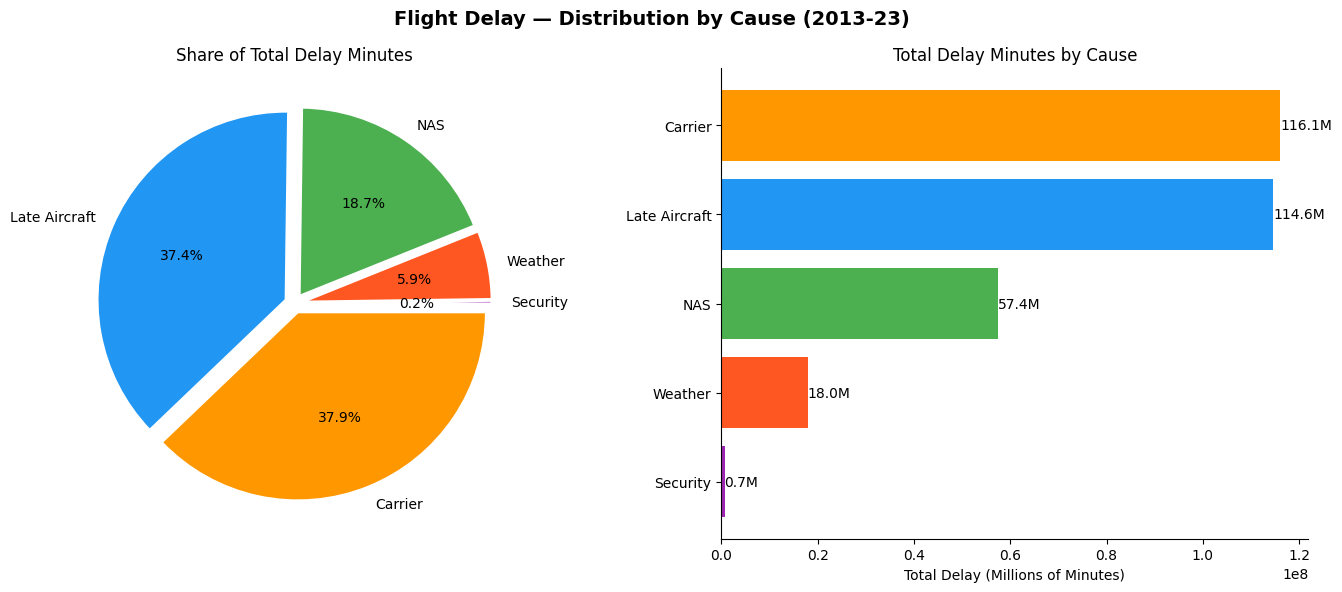

In [ ]:
# Overall Cause Distribution

cause_totals = df[delay_min_cols].sum()
cause_totals.index = cause_labels
sorted_c = cause_totals.sort_values(ascending=True)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Flight Delay — Distribution by Cause (2013-23)', fontsize=14, fontweight='bold')

# Pie
ax[0].pie(sorted_c,
            labels=sorted_c.index,
            autopct='%1.1f%%',
            colors=PALETTE[:5],
            explode=[0.05]*5,
            wedgeprops={'edgecolor':'white','linewidth':1.5}
            )
ax[0].set_title('Share of Total Delay Minutes')

# Bar
bars = ax[1].barh(sorted_c.index,
                    sorted_c.values,
                    color=PALETTE[:5],
                    )
ax[1].set_xlabel('Total Delay (Millions of Minutes)')
ax[1].set_title('Total Delay Minutes by Cause')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
for bar, val in zip(bars, sorted_c.values):
    ax[1].text(bar.get_width(),
                bar.get_y() + bar.get_height()/2,
                f'{val/1e6:.1f}M',
                va='center',
                )

plt.tight_layout()
plt.savefig(SAVE_DIR + '01_delay_cause_distribution.png')
plt.show()

In [ ]:
# Diagnostic: verify delay cause totals and column mapping
totals = df[delay_min_cols].sum()
print("Total delay minutes by column (raw):")
for col, label in zip(delay_min_cols, cause_labels):
    print(f"  {col} -> {label}: {totals[col]:,.0f} min ({totals[col]/totals.sum()*100:.1f}%)")

Total delay minutes by column (raw):
  carrier_delay -> Carrier: 116,074,254 min (37.9%)
  weather_delay -> Weather: 17,968,008 min (5.9%)
  nas_delay -> NAS: 57,363,133 min (18.7%)
  security_delay -> Security: 690,311 min (0.2%)
  late_aircraft_delay -> Late Aircraft: 114,553,938 min (37.4%)


### Some insights from above plot
1. Late Aircarft is the most prominent reason.
2. Contrast to general opinion such as weather which is significantly less.
3. Cascading effect for late Aircrafts make it even worse.
4. Carrier Delay is the second most prominent reason.
5. Both the top 2 delays are logistic reasons - need to improve logistics.
5. Security reasons is the least (almost negligible) - no updates needed.

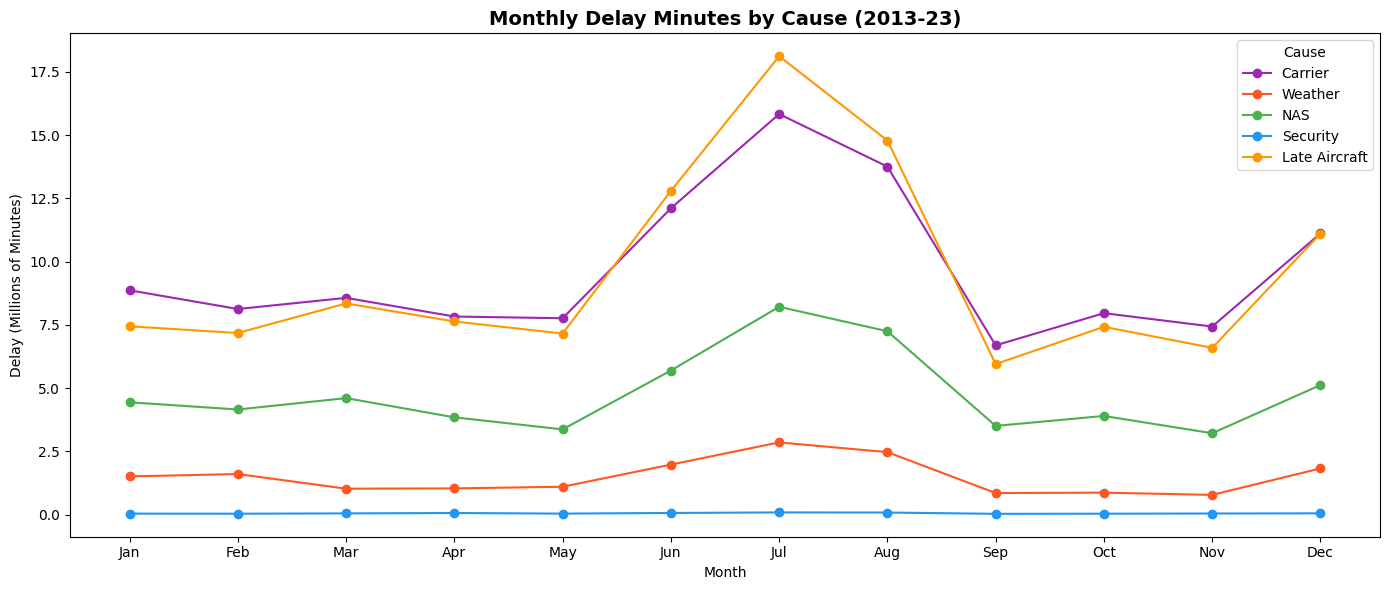

In [ ]:
# Monthly Cause Distribution

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_cause = df.groupby('month')[delay_min_cols].sum() / 1e6
monthly_cause.columns = cause_labels
monthly_cause.index = month_names

fig, ax = plt.subplots(figsize=(14, 6))
for i, cause in enumerate(cause_labels):
    ax.plot(month_names,
            monthly_cause[cause],
            marker='o',
            color=PALETTE[i],
            label=cause,
            )

ax.set_title('Monthly Delay Minutes by Cause (2013-23)', fontsize=14, fontweight='bold')
ax.set_ylabel('Delay (Millions of Minutes)')
ax.set_xlabel('Month')
ax.legend(title='Cause')
plt.tight_layout()
plt.savefig(SAVE_DIR + '02_monthly_cause_lines.png')
plt.show()

In [ ]:
# Derived features
df['total_delay_min'] = df[delay_min_cols].sum(axis=1)
df['delay_rate'] = np.where(df['arr_flights'] > 0, df['arr_del15'] / df['arr_flights'] * 100, 0)
df['avg_delay_min'] = np.where(df['arr_del15'] > 0, df['total_delay_min'] / df['arr_del15'], 0)
print(df.shape)
df.head()

(82348, 24)


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,total_delay_min,delay_rate,avg_delay_min
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,1.0,1375.0,71.0,761.0,118.0,0.0,425.0,1375.0,14.606742,105.769231
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,1.0,799.0,218.0,1.0,62.0,0.0,518.0,799.0,16.129032,79.900000
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,766.0,56.0,188.0,78.0,0.0,444.0,766.0,16.129032,76.600000
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,1.0,1397.0,471.0,320.0,388.0,0.0,218.0,1397.0,18.181818,116.416667
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,1530.0,628.0,0.0,134.0,0.0,768.0,1530.0,23.913043,69.545455


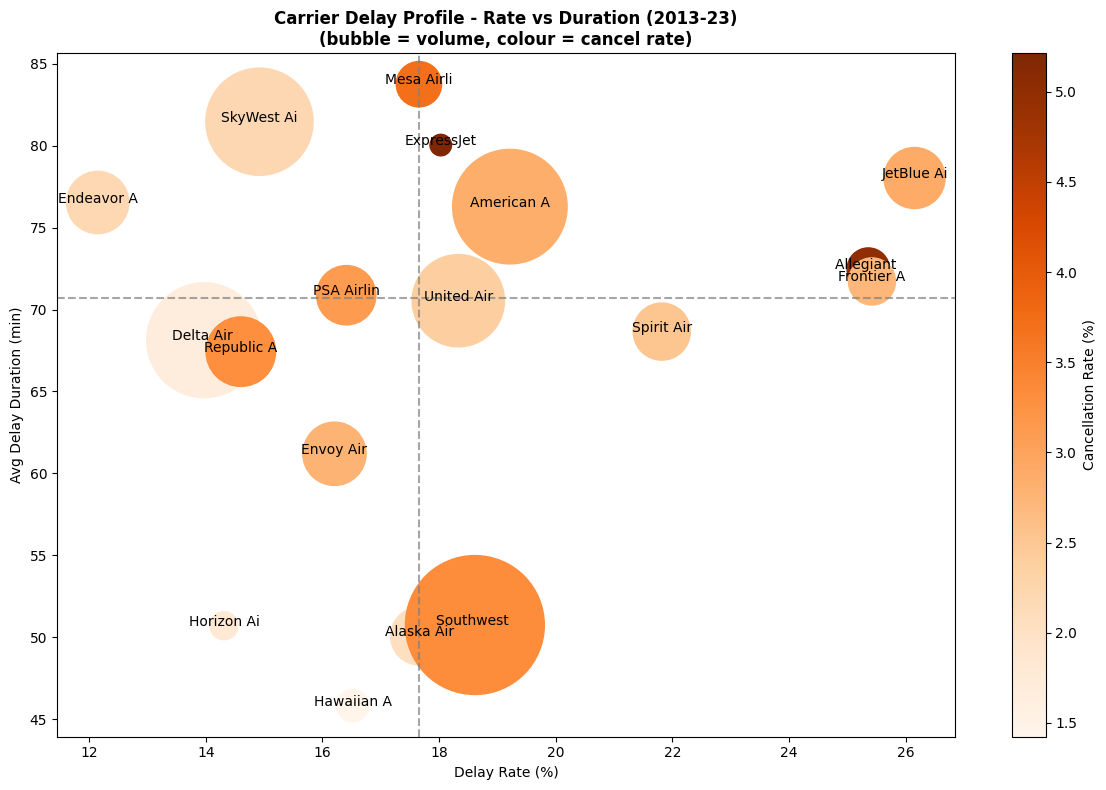

In [ ]:
# Carrier Profile

# Create aggregator for Carrier
agg_cols_dict = {
    'total_flights': ('arr_flights', 'sum'),
    'total_delayed': ('arr_del15', 'sum'),
    'total_delay_min': ('total_delay_min', 'sum'),
    'cancelled': ('arr_cancelled', 'sum'),
}

ca_agg = df.groupby('carrier_name').agg(**agg_cols_dict).reset_index()
# print(ca_agg.head())
# print(ca_agg)

ca_agg['delay_rate'] = ca_agg['total_delayed'] / ca_agg['total_flights'] * 100
ca_agg['avg_delay_min'] = ca_agg['total_delay_min'] / ca_agg['total_delayed']
ca_agg['cancel_rate'] = ca_agg['cancelled'] / ca_agg['total_flights'] * 100
ca_agg['short_name'] = ca_agg['carrier_name'].apply(lambda x: x[:10])

ca = ca_agg.copy()
ca['bubble_size'] = (ca['total_flights'] / ca['total_flights'].max()) * 1e4
# print(ca.head())

fig, ax = plt.subplots(figsize=(12, 8))
# 1. Darker color - higher cancellation rate
# 2. Bubble Size - Volume the carrier handles
# 3. Towards left - less delay rate
# 4. Towards bottom - less delay duration
sc = ax.scatter(ca['delay_rate'],
                ca['avg_delay_min'],
                s = ca['bubble_size'],
                c = ca['cancel_rate'],
                cmap = 'Oranges',
                )
plt.colorbar(sc, ax=ax, label='Cancellation Rate (%)')

for _, row in ca.iterrows():
    ax.annotate(row['short_name'],
                (row['delay_rate'], row['avg_delay_min']),
                ha='center',
                )

ax.set_xlabel('Delay Rate (%)')
ax.set_ylabel('Avg Delay Duration (min)')
ax.set_title('Carrier Delay Profile - Rate vs Duration (2013-23)\n(bubble = volume, colour = cancel rate)', fontweight='bold')
ax.axhline(ca['avg_delay_min'].median(), color='grey', linestyle='--', alpha=0.7)
ax.axvline(ca['delay_rate'].median(), color='grey', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(SAVE_DIR + '03_carrier_bubble.png')
plt.show()

1. Darker the color - higher cancellation rate
2. Bubble Size - Volume the carrier handles
3. Towards left - less delay rate
4. Towards bottom - less delay duration

Note - Avg delay duration may not be a good factor, as 60 to 70 mins for most of them seems to be affected by the extreme cases, bringing the avg higher.

### ToDo: Year-by-Year imrpovement/changes in each factor of delay. (Late Aircraft, Carrier, NAS, Weather, Security)

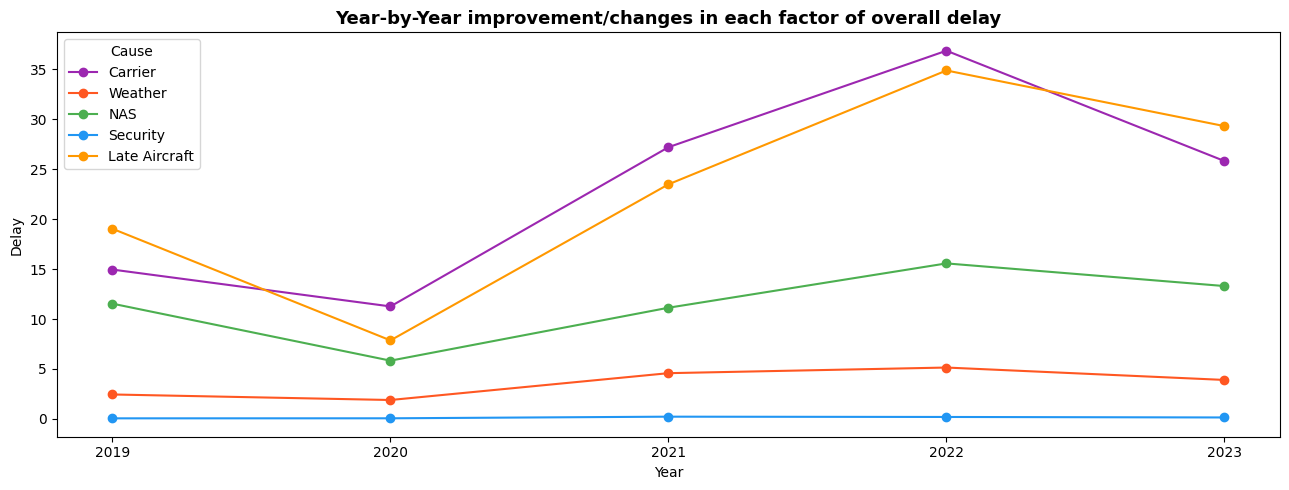

In [ ]:

plt_col = [c for c in delay_min_cols if c in df.columns]
yearly = df.groupby('year')[delay_min_cols].sum() / 1e6
yearly_cols = cause_labels
figure, axis = plt.subplots(figsize= (13, 5))
for i, j in enumerate[str](plt_col):
  label = cause_labels[delay_min_cols.index(j)]
  axis.plot(yearly.index.astype(int),
            yearly[j],
            marker='o',
            color=PALETTE[i],
            label=label,
            )
axis.set_title('Year-by-Year improvement/changes in each factor of overall delay', fontsize=13, fontweight='bold')
axis.set_ylabel('Delay')
axis.set_xlabel('Year')
axis.legend(title='Cause')
axis.set_xticks(yearly.index.astype(int))
plt.tight_layout()
plt.savefig(SAVE_DIR + 'yearlychange.png')
plt.show()

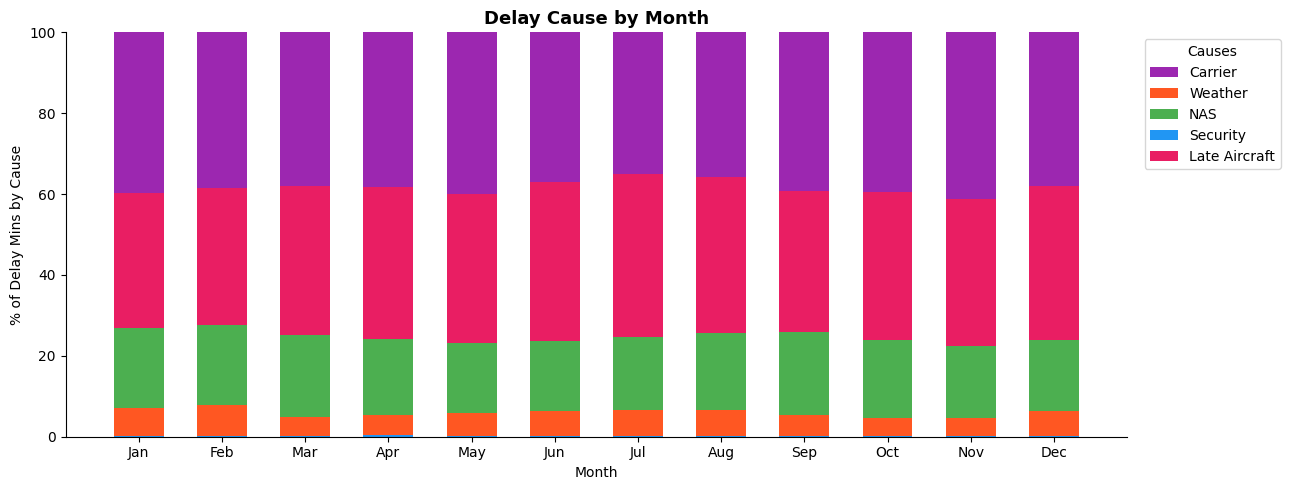

In [ ]:
#Global picture of how the primary delay causes vary by the month

# month
NEW_PALETTE = ['#9C27B0', '#FF5722', '#4CAF50', '#2196F3', '#E91E63']
bymonth = df.groupby('month')[delay_min_cols].sum()
bymonth.columns = cause_labels
bymonth['total'] = bymonth.sum(axis=1)
bymonth_pct = bymonth[cause_labels].div(bymonth['total'], axis=0) * 100
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
bymonth_pct.index = months
order = bymonth_pct.mean().sort_values(ascending=True).index.tolist()
figure, axis = plt.subplots(figsize = (13, 5))
bottom = np.zeros(12)
for i, j in enumerate[str](order):
  k = cause_labels.index(j)
  axis.bar(months, bymonth_pct[j].values, bottom=bottom, label=j, color=NEW_PALETTE[k], width=0.6)
  bottom = bottom + bymonth_pct[j].values
from matplotlib.patches import Patch
legend_elem = [Patch(facecolor=NEW_PALETTE[i], label=cause_labels[i]) for i in range(len(cause_labels))]
axis.legend(handles=legend_elem, title='Causes', bbox_to_anchor=(1.01, 1), loc='upper left')
axis.set_ylabel('% of Delay Mins by Cause')
axis.set_xlabel('Month')
axis.set_title('Delay Cause by Month', fontsize=13, fontweight='bold')
axis.set_ylim(0, 100)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_DIR + '07_cause_breakdown_by_month.png')
plt.show()